# Spaceship Titanic

Predict which passengers are transported to an alternate dimension

- Current Rank: 1179/2106 (Top 56% )
- Current Score: 0.79728 / Best Score: 0.82183

### File and Data Field Descriptions

<details>
<summary>Click to expand</summary>

train.csv - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
+ PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the 
group. People in a group are often family members, but not always.
+ HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
+ CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
+ Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
+ Destination - The planet the passenger will be debarking to.
+ Age - The age of the passenger.
+ VIP - Whether the passenger has paid for special VIP service during the voyage.
+ RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
+ Name - The first and last names of the passenger.
+ Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

+ test.csv - Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of Transported for the passengers in this set.
sample_submission.csv - A submission file in the correct format.
+ PassengerId - Id for each passenger in the test set.
+ Transported - The target. For each passenger, predict either True or False.

</details>

In [1]:
from __future__ import annotations

import math
import os
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFECV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from tensorflow.keras import Sequential, layers, callbacks, optimizers, losses, metrics

In [2]:
random_state = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [3]:
dtype={
    'Age': 'float32',
    'RoomService': 'float32',
    'FoodCourt': 'float32',
    'ShoppingMall': 'float32',
    'Spa': 'float32',
    'VRDeck': 'float32'}

In [4]:
# Importing the dataset
train = pd.read_csv('data/space/train.csv', index_col='PassengerId', dtype=dtype)
test = pd.read_csv('data/space/test.csv', index_col='PassengerId', dtype=dtype)

In [5]:
def feature_engineering(df: pd.DataFrame):
    
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['CryoSleep'] = df['CryoSleep'].fillna(False)
    df['VIP'] = df['VIP'].fillna(False)
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['RoomService'] = df['RoomService'].fillna(0)
    df['FoodCourt'] = df['FoodCourt'].fillna(0)
    df['ShoppingMall'] = df['ShoppingMall'].fillna(0)
    df['Spa'] = df['Spa'].fillna(0)
    df['VRDeck'] = df['VRDeck'].fillna(0)
    df['TotalServicesFee'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = df['Num'].astype(int)
    df['HomePlanet'] = df['HomePlanet'].fillna('Unknown')
    df['Destination'] = df['Destination'].fillna('Unknown')
    df['LastName'] = df['Name'].str.split(' ').str[-1] # TODO: base on last name we can detect family and group passengers
    df['Family Size'] = df['LastName'].map(df['LastName'].value_counts())
    df['Family Size'] = df['Family Size'].fillna(1) # if last name is unique, then family size is 1
    df['Is Alone'] = (df['Family Size'] == 1).astype(int)

    df[['VIP', 'CryoSleep']] = df[['VIP', 'CryoSleep']].astype(int)

    cols = [
        'Name',
        'Cabin',
        'LastName'
    ]
    
    df = df.drop(cols, axis=1)

    one_hot_columns = ['HomePlanet', 'Destination', 'Side', 'Deck']
    # One-hot-encode categorical columns
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    for col in one_hot_columns:
        if col in df.columns:
            transformed = ohe.fit_transform(df[[col]])
            ohe_df = pd.DataFrame(transformed,
                                  columns=[f"{col}_{cat}" for cat in ohe.categories_[0]],
                                  index=df.index)
            df = pd.concat([df, ohe_df], axis=1)
            df = df.drop(col, axis=1)
    
    # Scale numeric columns (optional, but can help with training) using StandardScaler
    scaler = MinMaxScaler()
    num_columns = df.select_dtypes(include=[np.number]).columns

    # remove target column from scaling
    num_columns = num_columns.drop('Transported', errors='ignore')
    df[num_columns] = scaler.fit_transform(df[num_columns])

    df.columns = df.columns.str.replace(r'[\.\s\-]+', '_', regex=True).str.lower()

    return df

In [6]:
transformed_train = feature_engineering(train)

In [7]:
X = transformed_train.drop('transported', axis=1)
y = transformed_train['transported']

In [8]:
# prepare data for model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# calculate variance for each feature
X_train.var(axis=0).sort_values(ascending=False)

side_s                       0.249971
side_p                       0.249821
homeplanet_earth             0.249089
cryosleep                    0.226046
deck_f                       0.218491
destination_trappist_1e      0.217409
deck_g                       0.208333
homeplanet_europa            0.184875
destination_55_cancri_e      0.164891
homeplanet_mars              0.160213
deck_e                        0.08916
destination_pso_j318_5_22     0.08287
deck_b                       0.082046
deck_c                       0.078729
num                          0.073457
is_alone                     0.062156
deck_d                       0.051538
age                          0.032728
family_size                  0.029967
deck_a                       0.027802
homeplanet_unknown           0.023579
side_u                       0.022208
deck_u                       0.022208
vip                          0.021933
destination_unknown          0.019592
totalservicesfee             0.006034
foodcourt   

In [9]:
# Lets use Random Forest Classifier as a baseline model for detect overfitting and check feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
# feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)

                      feature  importance
9                         num    0.132931
8            totalservicesfee    0.120674
1                         age    0.106179
6                         spa    0.081390
4                   foodcourt    0.074647
0                   cryosleep    0.067989
7                      vrdeck    0.067186
10                family_size    0.065618
3                 roomservice    0.064921
5                shoppingmall    0.063849
12           homeplanet_earth    0.021378
28                     deck_f    0.013117
27                     deck_e    0.012104
21                     side_s    0.011985
29                     deck_g    0.011724
13          homeplanet_europa    0.011548
20                     side_p    0.011029
18    destination_trappist_1e    0.010012
14            homeplanet_mars    0.008936
16    destination_55_cancri_e    0.008570
25                     deck_c    0.005996
17  destination_pso_j318_5_22    0.005677
11                   is_alone    0

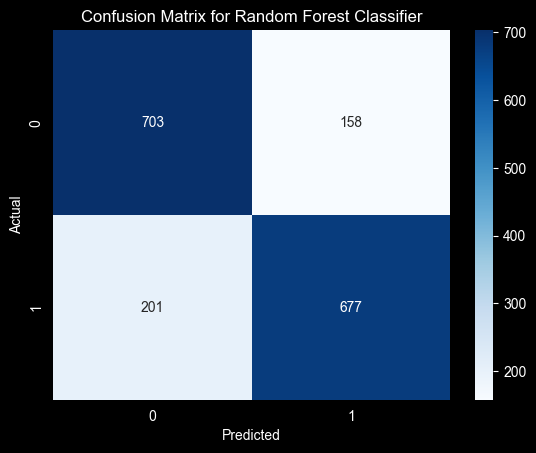

In [11]:
# Draw confusion matrix for Random Forest model using seaborn heatmap
y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

In [12]:
# Classification report for Random Forest model
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.78      0.82      0.80       861
        True       0.81      0.77      0.79       878

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



In [13]:
# Check accuracy of Random Forest model using cross-validation

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean()}")

Cross-validation scores: [0.8023005  0.7922358  0.79654925 0.79870597 0.81510791]
Mean cross-validation score: 0.8009798861126771


In [14]:
# let's train model base on feature importance
# importance treshold = 0.01

important_cols = feature_importance_df[feature_importance_df['importance'] > 0.01]['feature'].values
X_train_important = X_train[important_cols]
X_test_important = X_test[important_cols]

# Train Random Forest model on important features
rf_model_important = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_important.fit(X_train_important, y_train)

# Check accuracy of Random Forest model on important features using cross-validation
cv_scores_important = cross_val_score(rf_model_important, X_train_important, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Cross-validation scores (important features): {cv_scores_important}")
print(f"Mean cross-validation score (important features): {cv_scores_important.mean()}")

Cross-validation scores (important features): [0.80086269 0.79726815 0.79798706 0.80445723 0.81366906]
Mean cross-validation score (important features): 0.8028488381113943


In [15]:
# let's train model base on high variance columns
# variance treshold = 0.005

high_variance_cols = X_train.var(axis=0)[X_train.var(axis=0) > 0.005].index
X_train_high_var = X_train[high_variance_cols]
X_test_high_var = X_test[high_variance_cols]

# Train Random Forest model on high variance features
rf_model_high_var = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_high_var.fit(X_train_high_var, y_train)

# Check accuracy of Random Forest model on high variance features using cross-validation
cv_scores_high_var = cross_val_score(rf_model_high_var, X_train_high_var, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Cross-validation scores (high variance features): {cv_scores_high_var}")
print(f"Mean cross-validation score (high variance features): {cv_scores_high_var.mean()}")

Cross-validation scores (high variance features): [0.73975557 0.7325665  0.74047448 0.75485262 0.75899281]
Mean cross-validation score (high variance features): 0.7453283958024092


In [16]:
accuracy_list = []

for k in range(1, X_train.shape[1]+1):

    print(f'Iteration {k}/{X_train.shape[1]}, completed % : {k/X_train.shape[1]*100:.2f}%', end='\r')

    selector = SelectKBest(score_func=mutual_info_classif, k=k) # our case is classification with numerical features

    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_selected, y_train)

    y_pred = clf.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_list.append(accuracy)

In [17]:
# let's draw most 5 best features based on accuracy_list

best_k = np.argmax(accuracy_list) + 1
print(f'Best K: {best_k}, Accuracy: {accuracy_list[best_k-1]:.4f}')

Best K: 25, Accuracy: 0.7999


In [18]:
rfecv = RFECV(estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), step=1, cv=cv, scoring="accuracy", n_jobs=-1)
rfecv.fit(X_train, y_train)

best_k = rfecv.n_features_
selected_features = X_train.columns[rfecv.support_]
best_score = rfecv.cv_results_["mean_test_score"].max()

print(f"Best k: {best_k}")
print(f"CV accuracy: {best_score:.4f}")
print(f"Selected: {selected_features}")

Best k: 25
CV accuracy: 0.8030
Selected: Index(['cryosleep', 'age', 'roomservice', 'foodcourt', 'shoppingmall', 'spa',
       'vrdeck', 'totalservicesfee', 'num', 'family_size', 'is_alone',
       'homeplanet_earth', 'homeplanet_europa', 'homeplanet_mars',
       'homeplanet_unknown', 'destination_55_cancri_e',
       'destination_pso_j318_5_22', 'destination_trappist_1e', 'side_p',
       'side_s', 'deck_b', 'deck_c', 'deck_e', 'deck_f', 'deck_g'],
      dtype='str')


In [9]:
selected_features = ['cryosleep', 'age', 'roomservice', 'foodcourt', 'shoppingmall', 'spa',
       'vrdeck', 'totalservicesfee', 'num', 'family_size', 'is_alone',
       'homeplanet_earth', 'homeplanet_europa', 'homeplanet_mars',
       'homeplanet_unknown', 'destination_55_cancri_e',
       'destination_pso_j318_5_22', 'destination_trappist_1e', 'side_p',
       'side_s', 'deck_b', 'deck_c', 'deck_e', 'deck_f', 'deck_g']

In [ ]:
# TODO: use Optuna on RandomForestClassifier to find best hyperparameters and then use feature importance from best model to select features for DNN model

In [10]:
X_test_selected = X_test[selected_features]
X_train_selected = X_train[selected_features]

In [11]:
# Callbacks

# Early stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',  # Metric to monitor
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored metric
)


root_logdir = os.path.join(os.curdir, "logs")

def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir() # example: "logs/run_2024_06_01-12_00_00"


# TensorBoard callback for visualizing training progress
tensorboard_callback = callbacks.TensorBoard(
    log_dir=run_logdir,  # Directory where the logs will be saved
    histogram_freq=1,  # Frequency (in epochs) at which to compute activation and weight histograms for the layers of the model
    write_graph=True,  # Whether to visualize the graph in TensorBoard
    write_images=True  # Whether to write model weights to visualize as images in TensorBoard
)

In [12]:
model = Sequential([
    layers.Input(shape=(X_train_selected.shape[1],)),
    layers.Dense(256, activation='selu', kernel_initializer='lecun_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='selu', kernel_initializer='lecun_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(16, activation='selu', kernel_initializer='lecun_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
    ])

model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.003), # TODO: implement learning rate scheduler
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy(),
             metrics.AUC(),
             metrics.Precision(),
             metrics.Recall()]
)

218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_8: 0.6001 - binary_accuracy: 0.5910 - loss: 18.0112 - precision_8: 0.5991 - recall_8: 0.5666


(np.float64(9.999999747378752e-06),
 np.float64(9.3859281539917),
 np.float64(0.6727452874183655),
 np.float64(1.0592977489743916))

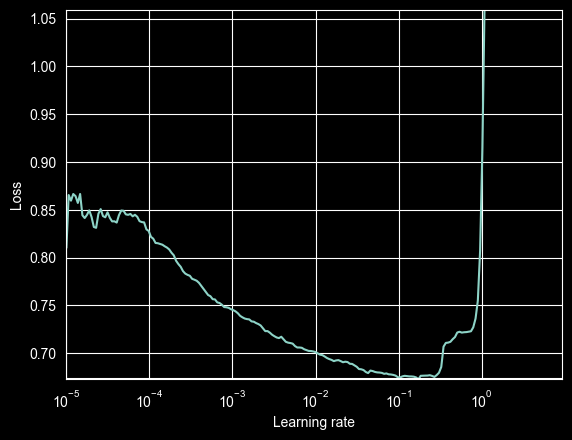

In [66]:

K = tf.keras.backend

class ExponentialLearningRate(callbacks.Callback):

    def __init__(self, factor):
        super().__init__()
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        # get current LR
        lr = K.get_value(self.model.optimizer.learning_rate)
        self.rates.append(lr)
        self.losses.append(logs.get("loss"))
        # compute new LR
        new_lr = lr * self.factor
        # set new LR (works with modern Keras)
        self.model.optimizer.learning_rate.assign(new_lr)

def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-5, max_rate=10.0):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = np.exp(np.log(max_rate / min_rate) / iterations)

    lr_var = model.optimizer.learning_rate
    init_lr = float(lr_var.numpy())
    lr_var.assign(min_rate)

    exp_lr = ExponentialLearningRate(factor)
    model.fit(X, y, epochs=epochs, batch_size=batch_size, callbacks=[exp_lr])

    lr_var.assign(init_lr)
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

def plot_lr_vs_loss(rates, _losses):
    plt.plot(rates, _losses)
    plt.gca().set_xscale('log')
    plt.hlines(min(_losses), min(rates), max(rates))
    plt.axis((min(rates), max(rates), min(_losses), (_losses[0] + min(_losses)) / 2))
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")

batch_size = 32
rates, model_losses = find_learning_rate(model, X_train_selected, y_train, epochs=1, batch_size=batch_size)
plot_lr_vs_loss(rates, model_losses)
plt.axis((min(rates), max(rates), min(model_losses), (model_losses[0] + min(model_losses)) / 1.4))

In [72]:
model.optimizer.learning_rate.assign(0.005)

<tf.Tensor: shape=(), dtype=float32, numpy=0.004999999888241291>

In [73]:
model.fit(
    X_train_selected, y_train,
    validation_data=(X_test_selected, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, tensorboard_callback]
)

Epoch 1/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc_8: 0.8563 - binary_accuracy: 0.7672 - loss: 0.4641 - precision_8: 0.7812 - recall_8: 0.7466 - val_auc_8: 0.8703 - val_binary_accuracy: 0.7884 - val_loss: 0.4381 - val_precision_8: 0.8021 - val_recall_8: 0.7711
Epoch 2/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc_8: 0.8650 - binary_accuracy: 0.7814 - loss: 0.4525 - precision_8: 0.7927 - recall_8: 0.7660 - val_auc_8: 0.8697 - val_binary_accuracy: 0.7481 - val_loss: 0.4644 - val_precision_8: 0.8860 - val_recall_8: 0.5752
Epoch 3/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc_8: 0.8656 - binary_accuracy: 0.7765 - loss: 0.4492 - precision_8: 0.7848 - recall_8: 0.7660 - val_auc_8: 0.8658 - val_binary_accuracy: 0.7596 - val_loss: 0.4666 - val_precision_8: 0.8134 - val_recall_8: 0.6800
Epoch 4/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc_8: 0.8703 - binary_accuracy: 0.7826 - loss: 0.4456 - precision_8: 0.7996 - recall_8: 0.7580 - val_auc_8: 0.8690 - val_binary_accuracy:

In [74]:
# lets check confusion matrix and classification report

y_pred = (model.predict(X_test_selected) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[693 168]
 [181 697]]
              precision    recall  f1-score   support

       False       0.79      0.80      0.80       861
        True       0.81      0.79      0.80       878

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [13]:
class OneCycleScheduler(callbacks.Callback):

    def __init__(
        self,
        iterations: int,
        max_rate: float,
        start_rate: Optional[float] = None,
        last_iterations: Optional[int] = None,
        last_rate: Optional[float] = None,
    ) -> None:
        super().__init__()
        self.iterations: int = iterations
        self.max_rate: float = max_rate
        self.start_rate: float = start_rate if start_rate is not None else max_rate / 10.0
        self.last_iterations: int = last_iterations if last_iterations is not None else iterations // 10 + 1
        self.half_iteration: int = (iterations - self.last_iterations) // 2
        self.last_rate: float = last_rate if last_rate is not None else self.start_rate / 1000.0
        self.iteration: int = 0

    def _interpolate(self, iter1: int, iter2: int, rate1: float, rate2: float) -> float:
        return ((rate2 - rate1) * (self.iteration - iter1) / (iter2 - iter1)) + rate1

    def on_batch_begin(self, batch: int, logs: Optional[dict] = None) -> None:
        if self.iteration < self.half_iteration:
            # Warm‑up phase
            rate = self._interpolate(0, self.half_iteration, self.start_rate, self.max_rate)
        elif self.iteration < 2 * self.half_iteration:
            # Cool‑down phase
            rate = self._interpolate(
                self.half_iteration,
                2 * self.half_iteration,
                self.max_rate,
                self.start_rate,
            )
        else:
            # Final annealing phase
            rate = self._interpolate(
                2 * self.half_iteration,
                self.iterations,
                self.start_rate,
                self.last_rate,
            )

        self.iteration += 1

        lr = self.model.optimizer.learning_rate  # type: ignore[attr-defined]
        if hasattr(lr, "assign"):
            lr.assign(rate)
        else:
            self.model.optimizer.learning_rate = rate  # type: ignore[assignment]

In [37]:
n_epochs = 100
batch_size = 64

onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs, max_rate=0.05)
history = model.fit(X_train_selected, y_train,
                    epochs=n_epochs,
                    batch_size=batch_size,
                    validation_data=(X_test_selected, y_test),
                    callbacks=[onecycle, early_stopping, tensorboard_callback])

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc_3: 0.8815 - binary_accuracy: 0.7975 - loss: 0.4283 - precision_3: 0.8071 - recall_3: 0.7854 - val_auc_3: 0.8839 - val_binary_accuracy: 0.7907 - val_loss: 0.4157 - val_precision_3: 0.7968 - val_recall_3: 0.7859
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc_3: 0.8778 - binary_accuracy: 0.7935 - loss: 0.4371 - precision_3: 0.8012 - recall_3: 0.7843 - val_auc_3: 0.8835 - val_binary_accuracy: 0.7907 - val_loss: 0.4175 - val_precision_3: 0.7881 - val_recall_3: 0.8007
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc_3: 0.8761 - binary_accuracy: 0.7941 - loss: 0.4374 - precision_3: 0.8020 - recall_3: 0.7846 - val_auc_3: 0.8850 - val_binary_accuracy: 0.7964 - val_loss: 0.4150 - val_precision_3: 0.7892 - val_recall_3: 0.8144
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc_3: 0.8758 - binary_accuracy: 0.7951 - loss: 0.4397 - precision_3: 0.8001 - recall_3: 0.7903 - val_auc_3: 0.8843 - val_binary_accurac

In [30]:
n_epochs = 100
batch_size = 128

onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs, max_rate=0.05)

model.fit(
    X_train_selected, y_train,
    validation_data=(X_test_selected, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, tensorboard_callback, onecycle]
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - auc_3: 0.8728 - binary_accuracy: 0.7863 - loss: 0.4445 - precision_3: 0.7922 - recall_3: 0.7800 - val_auc_3: 0.8816 - val_binary_accuracy: 0.7901 - val_loss: 0.4195 - val_precision_3: 0.7743 - val_recall_3: 0.8246
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc_3: 0.8793 - binary_accuracy: 0.7934 - loss: 0.4333 - precision_3: 0.8037 - recall_3: 0.7800 - val_auc_3: 0.8821 - val_binary_accuracy: 0.7861 - val_loss: 0.4200 - val_precision_3: 0.7709 - val_recall_3: 0.8200
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc_3: 0.8779 - binary_accuracy: 0.7949 - loss: 0.4333 - precision_3: 0.8029 - recall_3: 0.7854 - val_auc_3: 0.8823 - val_binary_accuracy: 0.7798 - val_loss: 0.4206 - val_precision_3: 0.8252 - val_recall_3: 0.7153
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc_3: 0.8788 - binary_accuracy: 0.7964 - loss: 0.4345 - precision_3: 0.8038 - recall_3: 0.7877 - val_auc_3: 0.8793 - val_binary_accuracy: 0.7

In [23]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(0.01, n_epochs)

lr_scheduler = callbacks.LearningRateScheduler(exponential_decay_fn)

history = model.fit(
    X_train_selected, y_train,
    validation_data=(X_test_selected, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, tensorboard_callback, lr_scheduler]
)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc_1: 0.8692 - binary_accuracy: 0.7875 - loss: 0.4502 - precision_1: 0.8045 - recall_1: 0.7631 - val_auc_1: 0.8771 - val_binary_accuracy: 0.7769 - val_loss: 0.4245 - val_precision_1: 0.7759 - val_recall_1: 0.7847 - learning_rate: 0.0100
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc_1: 0.8690 - binary_accuracy: 0.7831 - loss: 0.4502 - precision_1: 0.7909 - recall_1: 0.7737 - val_auc_1: 0.8792 - val_binary_accuracy: 0.7757 - val_loss: 0.4409 - val_precision_1: 0.8720 - val_recall_1: 0.6515 - learning_rate: 0.0098
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc_1: 0.8768 - binary_accuracy: 0.7863 - loss: 0.4347 - precision_1: 0.8008 - recall_1: 0.7660 - val_auc_1: 0.8802 - val_binary_accuracy: 0.7849 - val_loss: 0.4298 - val_precision_1: 0.7490 - val_recall_1: 0.8633 - learning_rate: 0.0095
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc_1: 0.8748 - binary_accuracy: 0.7895 - loss: 0.4410 - precis

In [14]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(
        self,
        iterations: int,
        max_rate: float,
        start_rate: float | None = None,
        last_iterations: int | None = None,
        last_rate: float | None = None,
    ) -> None:
        super().__init__()
        self.iterations = iterations
        self.max_rate = max_rate
        self.start_rate = start_rate or max_rate / 10.0
        self.last_iterations = last_iterations or iterations // 10
        self.last_rate = last_rate or self.start_rate / 1000.0

        remaining = iterations - self.last_iterations
        self.half_iteration = remaining // 2

        self.phase1_end = self.half_iteration
        self.phase2_end = 2 * self.half_iteration
        self.phase3_end = self.phase2_end + self.last_iterations

        self.iteration = 0

    def _interpolate(self, i, i1, i2, r1, r2):
        return r1 + (r2 - r1) * (i - i1) / (i2 - i1)

    def on_train_batch_begin(self, batch, logs=None):
        i = min(self.iteration, self.iterations)

        if i < self.phase1_end:
            rate = self._interpolate(i, 0, self.phase1_end, self.start_rate, self.max_rate)
        elif i < self.phase2_end:
            rate = self._interpolate(
                i, self.phase1_end, self.phase2_end, self.max_rate, self.start_rate
            )
        else:
            rate = self._interpolate(
                i, self.phase2_end, self.phase3_end, self.start_rate, self.last_rate
            )

        self.iteration += 1

        lr = self.model.optimizer.learning_rate
        if hasattr(lr, "assign"):
            lr.assign(rate)
        else:
            self.model.optimizer.learning_rate = rate

one_cycle_scheduler = OneCycleScheduler(
    iterations=1000,
    max_rate=1e-3,
    start_rate=1e-4,
    last_iterations=100,
    last_rate=1e-5
)

In [20]:
n_epochs = 100

model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.01),
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy(),
             metrics.Precision(),
             metrics.Recall()]
)

history = model.fit(
    X_train_selected, y_train,
    validation_data=(X_test_selected, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stopping,
               one_cycle_scheduler]
)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - binary_accuracy: 0.7452 - loss: 0.5115 - precision_5: 0.7829 - recall_5: 0.6831 - val_binary_accuracy: 0.7556 - val_loss: 0.4722 - val_precision_5: 0.8024 - val_recall_5: 0.6845
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.7419 - loss: 0.5187 - precision_5: 0.7792 - recall_5: 0.6797 - val_binary_accuracy: 0.7556 - val_loss: 0.4722 - val_precision_5: 0.8024 - val_recall_5: 0.6845
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.7399 - loss: 0.5159 - precision_5: 0.7793 - recall_5: 0.6740 - val_binary_accuracy: 0.7556 - val_loss: 0.4721 - val_precision_5: 0.8024 - val_recall_5: 0.6845
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.7437 - loss: 0.5174 - precision_5: 0.7818 - recall_5: 0.6809 - val_binary_accuracy: 0.7568 - val_loss: 0.4718 - val_precision_5: 0.8029 - val_recall_5: 0.6868
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accur

In [78]:
test_transformed = feature_engineering(test)
test_selected = test_transformed[selected_features]

test_predictions = (model.predict(test_selected) > 0.5).astype(int).flatten()
y_pred = pd.Series(test_predictions, index=test.index, name='Transported')
submission = y_pred.astype(bool).to_frame().reset_index()

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
submission.to_csv('data/space/submission.csv', index=False)